# SHAP Analysis (Phase 4)

Feature importance via SHAP for the XGBoost yield model.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import joblib

if Path.cwd().name == 'notebooks':
    os.chdir('..')

from src.models.yield_model import (
    build_yield_dataset, prepare_Xy
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

## Load Data and Model

In [2]:
DAILY_CSV = 'data/raw/climate_daily_2015_2024.csv'
YIELD_CSV = 'data/raw/nhb_yield_mock_2015_2024.csv'

df = build_yield_dataset(DAILY_CSV, YIELD_CSV)
X, y, feature_cols = prepare_Xy(df)

# Use all data for SHAP analysis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Load or retrain XGBoost
xgb_path = Path('models/xgb_yield_best.json')
if xgb_path.exists():
    model = xgb.XGBRegressor()
    model.load_model(str(xgb_path))
else:
    print("No saved XGBoost model. Training fresh...")
    model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
    model.fit(X_scaled, y)

No saved XGBoost model. Training fresh...


## SHAP Waterfall Plot

Saved shap_waterfall.png


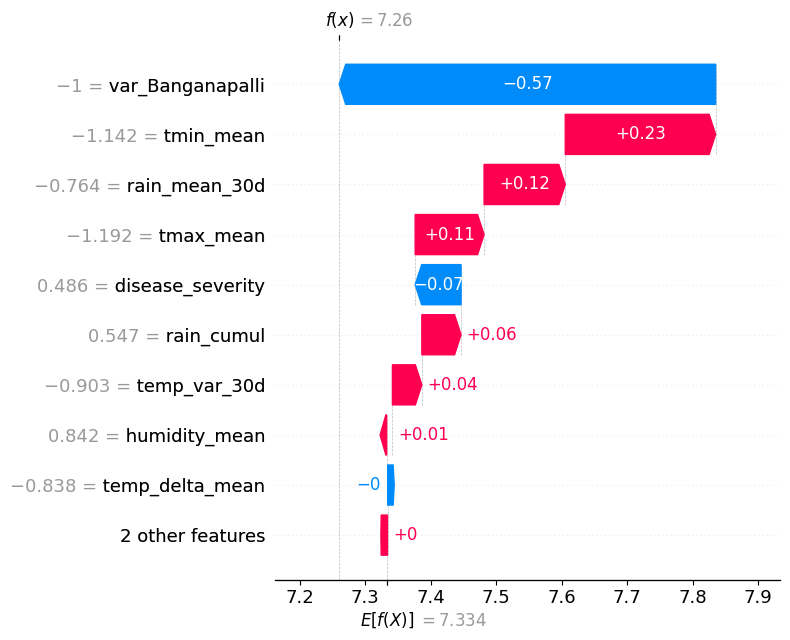

In [3]:
explainer = shap.Explainer(model, feature_names=feature_cols)
shap_values = explainer(X_scaled)

# Waterfall for first sample
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
plt.savefig('reports/figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
print("Saved shap_waterfall.png")

## SHAP Beeswarm Plot

In [4]:
plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig('reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
print("Saved shap_beeswarm.png")

Saved shap_beeswarm.png


## Feature Importance Ranking

In [5]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Feature Importance (SHAP):")
print(importance.to_string(index=False))

Feature Importance (SHAP):
         feature  mean_abs_shap
disease_severity       0.517740
var_Banganapalli       0.466818
      rain_cumul       0.112620
   rain_mean_30d       0.098882
    temp_var_30d       0.075885
       tmin_mean       0.067261
   humidity_mean       0.048705
       tmax_mean       0.048310
 temp_delta_mean       0.013452
        vpd_mean       0.002632
     var_Raspuri       0.000000


## Key Question

Does `disease_severity` appear in the top features?
If yes → confirms the **novel contribution** of coupling disease detection with yield prediction.